<h1>Wine database study</h1>

<h2>Gabriele Cerioli, BsC Physics UNITS, Internship ICTP</h2>

<img src="https://www.coravin.it/cdn/shop/articles/AdobeStock_791180394_549e319b-e031-4757-84c1-9796e2192a3d.jpg?v=1750068247" alt="Italian Trulli">

<h2>01) The database</h2>

In [1]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
Y = wine_quality.data.targets  

In [3]:
import numpy as np
import pandas as pd

# Conversione in matrici NumPy
x = X.to_numpy()   # oppure: x.values
y = Y.to_numpy()   # oppure: y.values

print("Shape di x:", x.shape)
print("Shape di y:", y.shape)
print(x)
print(y)
data_matrix=x
ground_truth=y

Shape di x: (6497, 11)
Shape di y: (6497, 1)
[[ 7.4   0.7   0.   ...  3.51  0.56  9.4 ]
 [ 7.8   0.88  0.   ...  3.2   0.68  9.8 ]
 [ 7.8   0.76  0.04 ...  3.26  0.65  9.8 ]
 ...
 [ 6.5   0.24  0.19 ...  2.99  0.46  9.4 ]
 [ 5.5   0.29  0.3  ...  3.34  0.38 12.8 ]
 [ 6.    0.21  0.38 ...  3.26  0.32 11.8 ]]
[[5]
 [5]
 [5]
 ...
 [6]
 [7]
 [6]]


<h3>Do we need to standardize the features to make them compatible?</h3>

<h3>Let's check the independence of the 11 proprierties</h3>

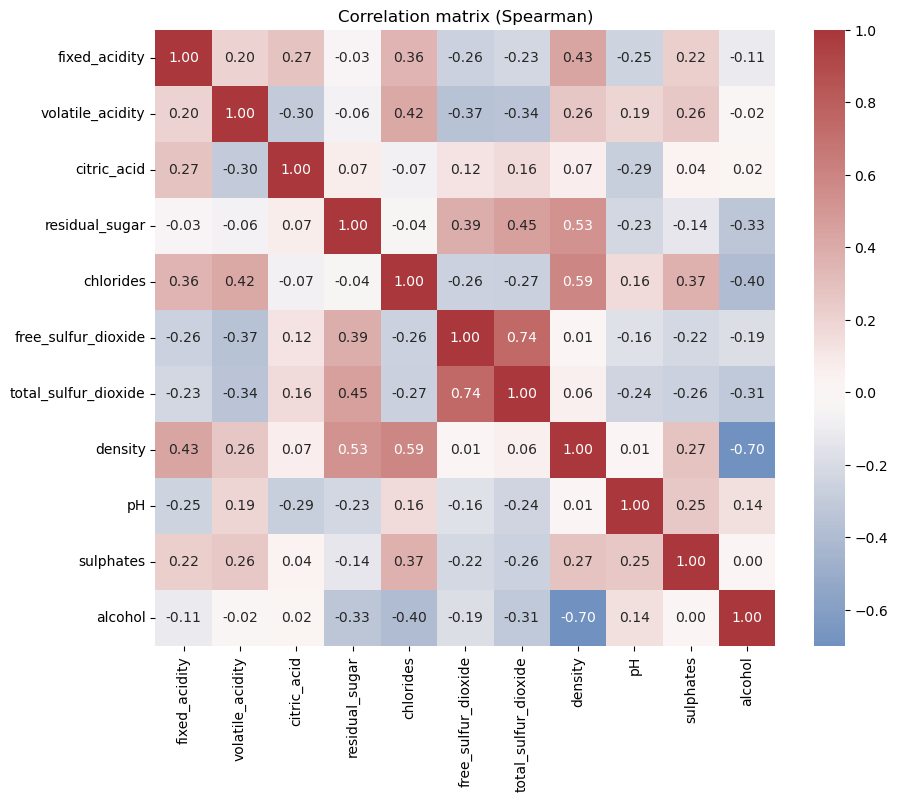

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

corr_spearman = X.corr(method='spearman')

plt.figure(figsize=(10,8))
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation matrix (Spearman)")
plt.show()

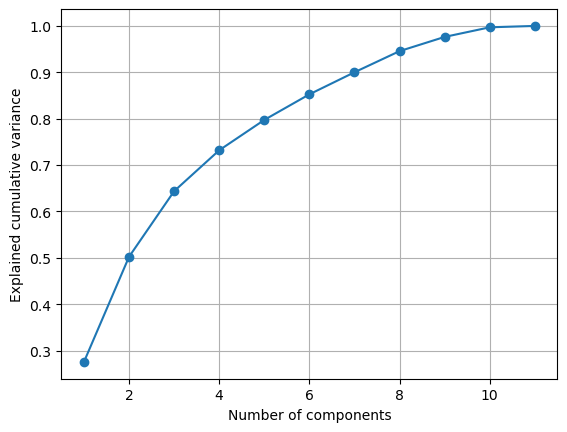

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xs = scaler.fit_transform(X)  # Standardise the components
pca = PCA()
pca.fit(Xs)
explained = np.cumsum(pca.explained_variance_ratio_)

import matplotlib.pyplot as plt
plt.plot(np.arange(1, len(explained)+1), explained, marker='o')
plt.xlabel('Number of components')
plt.ylabel('Explained cumulative variance')
plt.grid(True)
plt.show()


<h3>Maybe can we combine some redundant features?</h3>

<h3>Let's calcolate how much each feature weight on the quality score</h3>

In [24]:
wine_quality_united= pd.concat([X, Y], axis=1)

In [25]:
corr = wine_quality_united.corr(method='spearman')["quality"].sort_values(ascending=False)
print(corr)

quality                 1.000000
alcohol                 0.446925
citric_acid             0.105711
free_sulfur_dioxide     0.086865
pH                      0.032538
sulphates               0.029831
residual_sugar         -0.016891
total_sulfur_dioxide   -0.054777
fixed_acidity          -0.098154
volatile_acidity       -0.257806
chlorides              -0.295054
density                -0.322806
Name: quality, dtype: float64


In [ ]:
Y = Y.values.ravel() 

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


# standardizza per rendere comparabili i coefficienti
scaler = StandardScaler()
Xs = scaler.fit_transform(X)
model = LinearRegression()
model.fit(Xs, Y)

importances =pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)
print("Importances with linear regression:")
print(importances)


Importances with linear regression:
alcohol                 0.318465
residual_sugar          0.207228
sulphates               0.114312
free_sulfur_dioxide     0.105954
fixed_acidity           0.087741
pH                      0.070628
citric_acid            -0.015934
chlorides              -0.016945
total_sulfur_dioxide   -0.140237
density                -0.164815
volatile_acidity       -0.218603
dtype: float64


<h2>Clustering of the data</h2>

In [ ]:
def purity_score(y_true, y_pred):
    """
    Calcola la purity tra etichette vere (y_true) e assegnazioni di clustering (y_pred).
    
    Parameters:
    - y_true: array-like, etichette reali
    - y_pred: array-like, etichette di clustering
    
    Returns:
    - purity: float, valore tra 0 e 1
    """
    from sklearn.metrics import confusion_matrix

    # Matrice di contingenza: righe = classi vere, colonne = cluster
    contingency_matrix = confusion_matrix(y_true, y_pred)
    
    # Somma dei massimi per ogni colonna (cluster)
    max_per_cluster = np.max(contingency_matrix, axis=0)
    
    # Purezza = somma dei massimi / totale dei campioni
    purity = np.sum(max_per_cluster) / np.sum(contingency_matrix)
    
    return purity

In [ ]:
from sklearn.cluster import KMeans

n_clusters = 9
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(data_matrix)
cluster_assignments = kmeans.labels_
centroids = kmeans.cluster_centers_


<h3>PCA decomposition</h3>

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
data_2d = pca.fit_transform(data_matrix)
centroids_2d = pca.transform(centroids)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.scatter(data_2d[:, 0], data_2d[:, 1],
            c=cluster_assignments, cmap="viridis", alpha=0.6, edgecolor="k")
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c="red", marker="X", s=50, label="Centroidi")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-means Clusters in PCA Projection (all wines)")
plt.legend()
plt.grid(True)
plt.savefig("K-means Clusters in PCA Projection (all wines).pdf", format="pdf")
plt.show()


In [ ]:
print("Purity score of k-means:", purity_score(ground_truth,cluster_assignments))

<h2>Gaussian Mixtures </h2>

In [ ]:
from sklearn.mixture import GaussianMixture
n_clusters = 9

gmm = GaussianMixture(n_components=n_clusters)

gmm.fit(data_matrix)

soft_assignments = gmm.predict_proba(data_matrix)

hard_assignments = gmm.predict(data_matrix)

centroids = gmm.means_

#PCA and plotting:

pca = PCA(n_components=2)
data_2d = pca.fit_transform(data_matrix)
centroids_2d = pca.transform(centroids)

plt.figure(figsize=(12, 8))
plt.scatter(data_2d[:, 0], data_2d[:, 1],
            c=hard_assignments, cmap="viridis", alpha=0.6, edgecolor="k")
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c="red", marker="X", s=50, label="Centroidi")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Gaussian_mixtures Clusters in PCA Projection (all wines)")
plt.legend()
plt.grid(True)
plt.savefig("Gaussian_mixtures Clusters in PCA Projection (all wines).pdf", format="pdf")

plt.show()

print("Purity score of Gaussian_Mixtures:", purity_score(ground_truth,hard_assignments))

In [ ]:
unique_clusters, counts = np.unique(cluster_assignments, return_counts=True)

plt.figure(figsize=(12,8))
plt.bar(unique_clusters, counts, color="skyblue", edgecolor="black")
plt.xlabel("Cluster")
plt.ylabel("Number of points")
plt.title("Distribution of points per cluster (hard assignments)")
plt.xticks(unique_clusters)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.savefig("Distribution of points per cluster (hard assignments).pdf", format="pdf")

plt.show()


<h2>What if we divide red and white wines?</h2>

<h2>Red wines</h2>

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("winequality-red.csv", sep=";")
print(df.columns.tolist())

# Seleziona le colonne che ti interessano
selected_columns = ["fixed acidity", "volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density", "pH", "sulphates","alcohol"]

# Crea la matrice NumPy
data_matrix = df[selected_columns].to_numpy()
quality_selected_column=["quality"]
ground_truth=df[quality_selected_column].to_numpy()
print("Shape della matrice:", data_matrix.shape)
print(data_matrix)


In [ ]:

n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(data_matrix)
cluster_assignments = kmeans.labels_
centroids = kmeans.cluster_centers_

pca = PCA(n_components=2)
data_2d = pca.fit_transform(data_matrix)
centroids_2d = pca.transform(centroids)

plt.figure(figsize=(12, 8))
plt.scatter(data_2d[:, 0], data_2d[:, 1],
            c=cluster_assignments, cmap="viridis", alpha=0.6, edgecolor="k")
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c="red", marker="X", s=50, label="Centroidi")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-means Clusters in PCA Projection (red wines)")
plt.legend()
plt.grid(True)
plt.savefig("K-means Clusters in PCA Projection (red wines).pdf", format="pdf")

plt.show()

print("Purity score of k-means:", purity_score(ground_truth,cluster_assignments))

In [ ]:
n_clusters = 8

gmm = GaussianMixture(n_components=n_clusters)

gmm.fit(data_matrix)

soft_assignments = gmm.predict_proba(data_matrix)

hard_assignments = gmm.predict(data_matrix)

centroids = gmm.means_

#PCA and plotting:

pca = PCA(n_components=2)
data_2d = pca.fit_transform(data_matrix)
centroids_2d = pca.transform(centroids)

plt.figure(figsize=(12, 8))
plt.scatter(data_2d[:, 0], data_2d[:, 1],
            c=hard_assignments, cmap="viridis", alpha=0.6, edgecolor="k")
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c="red", marker="X", s=50, label="Centroidi")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Gaussian_mixtures Clusters in PCA Projection (red wines)")
plt.legend()
plt.grid(True)
plt.savefig("Gaussian_mixtures Clusters in PCA Projection (red wines).pdf", format="pdf")

plt.show()

print("Purity score of Gaussian_Mixtures:", purity_score(ground_truth,hard_assignments))

<h2>White wines</h2>

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("winequality-white.csv", sep=";")
print(df.columns.tolist())

# Seleziona le colonne che ti interessano
selected_columns = ["fixed acidity", "volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density", "pH", "sulphates","alcohol"]

# Crea la matrice NumPy
data_matrix = df[selected_columns].to_numpy()
quality_selected_column=["quality"]
ground_truth=df[quality_selected_column].to_numpy()
print("Shape della matrice:", data_matrix.shape)
print(data_matrix)

In [ ]:
n_clusters = 9
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(data_matrix)
cluster_assignments = kmeans.labels_
centroids = kmeans.cluster_centers_

pca = PCA(n_components=2)
data_2d = pca.fit_transform(data_matrix)
centroids_2d = pca.transform(centroids)

plt.figure(figsize=(12, 8))
plt.scatter(data_2d[:, 0], data_2d[:, 1],
            c=cluster_assignments, cmap="viridis", alpha=0.6, edgecolor="k")
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c="red", marker="X", s=50, label="Centroidi")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-means Clusters in PCA Projection (white wines)")
plt.legend()
plt.grid(True)
plt.savefig("K-means Clusters in PCA Projection (white wines).pdf", format="pdf")

plt.show()

print("Purity score of k-means:", purity_score(ground_truth,cluster_assignments))

In [ ]:
n_clusters = 9

gmm = GaussianMixture(n_components=n_clusters)

gmm.fit(data_matrix)

soft_assignments = gmm.predict_proba(data_matrix)

hard_assignments = gmm.predict(data_matrix)

centroids = gmm.means_

#PCA and plotting:

pca = PCA(n_components=2)
data_2d = pca.fit_transform(data_matrix)
centroids_2d = pca.transform(centroids)

plt.figure(figsize=(12, 8))
plt.scatter(data_2d[:, 0], data_2d[:, 1],
            c=hard_assignments, cmap="viridis", alpha=0.6, edgecolor="k")
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c="red", marker="X", s=50, label="Centroidi")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Gaussian_mixtures Clusters in PCA Projection (white wines)")
plt.legend()
plt.grid(True)
plt.savefig("Gaussian_mixtures Clusters in PCA Projection (white wines).pdf", format="pdf")

plt.show()

print("Purity score of Gaussian_Mixtures:", purity_score(ground_truth,hard_assignments))